<a href="https://colab.research.google.com/github/Shreyat2406/House-Price-Prediction/blob/main/Copy_of_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [ ]:
!pip install pandas numpy matplotlib scikit-learn

Data preprocessing:


In [ ]:
main_df = pd.read_csv("House_Price.csv")
main_df.head(10)

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,Unnamed: 4,HOUSE_TYPE,Unnamed: 6,Unnamed: 7,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,Independent House,Independent,House,for sale in,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,Independent House,Independent,House,for sale in,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,Independent House,Independent,House,for sale in,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,Independent House,Independent,House,for sale in,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert


In [ ]:
main_df.shape

(3968, 15)

In [ ]:
main_df.isnull().values.any()


np.True_

In [ ]:
main_df.isnull().sum()

,0
Flat_Price,0
EMI_Starts,0
BHK,0
css-11nfaq3,2
Unnamed: 4,2
HOUSE_TYPE,0
Unnamed: 6,2
Unnamed: 7,2
Purpose,2
Location,2


In [ ]:
main_df['Unnamed: 4'].unique()



array(['BHK', nan, 'RK', 'BH'], dtype=object)

In [ ]:
main_df['Unnamed: 6'].unique()

array(['Independent', nan], dtype=object)

In [ ]:
main_df['Area_Type'].unique()

array(['Build Up Area', 'Possession Starts'], dtype=object)

In [ ]:
main_df['Purpose'].unique()

array(['for sale in', nan], dtype=object)

In [ ]:
main_df['Location'].unique()

array(['Ballygunge, Kolkata', 'Barrackpore, Kolkata',
       'Santoshpur, Kolkata', 'Sarsuna, Kolkata', 'Madhyamgram, Kolkata',
       'Thakurpukur, Kolkata', 'Rajpur, Kolkata',
       'North Dum Dum, Kolkata', 'Dhakuria, Kolkata',
       'Shyambazar, Kolkata', 'Nazirabad, Kolkata', 'Joka, Kolkata',
       'Kasba, Kolkata', 'Barisha, Kolkata', 'Behala, Kolkata',
       'Taratala, Kolkata', 'Jodhpur Park, Kolkata',
       'Salt Lake City, Kolkata', 'New Town, Kolkata',
       'Mohispota, Kolkata', 'Maheshtala, Kolkata', 'Naihati, Kolkata',
       'Birati, Kolkata', 'Amtala, Kolkata', 'Gariahat, Kolkata',
       'New Barrakpur, Kolkata', 'Rajpur Sonarpur, Kolkata',
       'Khardah, Kolkata', 'Belghoria, Kolkata', 'Sodepur, Kolkata',
       'Baghbazar, Kolkata', 'Baghajatin, Kolkata', 'Nimta, Kolkata',
       'Lake Gardens, Kolkata', 'Khidirpur, Kolkata',
       'Kolutolla, Kolkata', 'Baguiati, Kolkata',
       'Diamond Harbour, Kolkata', 'Bantala, Kolkata',
       'Tollygunge, Kolkata', 

In [ ]:
main_df.rename(columns={'Unnamed: 4': 'House_type'}, inplace=True)
main_df.head(10)


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,HOUSE_TYPE,Unnamed: 6,Unnamed: 7,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,Independent House,Independent,House,for sale in,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,Independent House,Independent,House,for sale in,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,Independent House,Independent,House,for sale in,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,Independent House,Independent,House,for sale in,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert


In [ ]:
main_df.head(10)

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,HOUSE_TYPE,Unnamed: 6,Unnamed: 7,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,Independent House,Independent,House,for sale in,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,Independent House,Independent,House,for sale in,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,Independent House,Independent,House,for sale in,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,Independent House,Independent,House,for sale in,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert


## Dropping the unwanted columns

In [ ]:
new_df = main_df.drop(['HOUSE_TYPE', 'Unnamed: 6','Unnamed: 7','Purpose'], axis=1)
new_df.head(10)

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert


## handling Missing values

In [ ]:
new_df.isnull().sum()

,0
Flat_Price,0
EMI_Starts,0
BHK,0
css-11nfaq3,2
House_type,2
Location,2
Area_Type,0
Total_Sq.ft,0
Price_per_sq.ft,0
Owner_name,10


In [ ]:
new_df.shape


(3968, 11)

In [ ]:
df_clean = new_df.dropna()
df_clean.head(10)

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert


In [ ]:
df_clean.isnull().sum()

,0
Flat_Price,0
EMI_Starts,0
BHK,0
css-11nfaq3,0
House_type,0
Location,0
Area_Type,0
Total_Sq.ft,0
Price_per_sq.ft,0
Owner_name,0


In [ ]:
df_clean.shape

(3956, 11)

## feature engineering need to do
 1)normalize the price column
 2)create ine new column using feature engineering
 3)Area per BHK

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import re

def convert_price(price):
    if pd.isna(price):
        return None

    price = str(price).lower()

    # remove currency symbol and commas
    price = price.replace('₹', '').replace(',', '').strip()

    try:
        # extract numeric part
        number = float(re.findall(r'\d+\.?\d*', price)[0])

        if 'cr' in price:
            return number * 10000000
        elif 'lac' in price or 'l' in price:
            return number * 100000
        elif 'k' in price:
            return number * 1000
        else:
            return number
    except:
        return None




In [ ]:
df_clean['EMI_Starts_in_Number'] = df_clean['EMI_Starts'].apply(convert_price)

/tmp/ipykernel_6520/3830130873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['EMI_Starts_in_Number'] = df_clean['EMI_Starts'].apply(convert_price)


In [ ]:
df_clean['Flat_Price_in_Number'] = df_clean['Flat_Price'].apply(convert_price)
df_clean.head(10)



/tmp/ipykernel_6520/634404266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Flat_Price_in_Number'] = df_clean['Flat_Price'].apply(convert_price)


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,Housing Expert,16950.0,3200000.0
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,Housing Expert,36700.0,6930000.0
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,Housing Expert,21180.0,4000000.0
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,Housing Expert,47160.0,9500000.0
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,Housing Expert,149000.0,30000000.0


In [ ]:
import re

df_clean['BHK_Number'] = df_clean['BHK'].astype(str).str.extract('(\d+)').astype(int)
df_clean.head(5)


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6520/3935866439.py:3: SyntaxWarning: invalid escape sequence '\d'
  df_clean['BHK_Number'] = df_clean['BHK'].astype(str).str.extract('(\d+)').astype(int)
/tmp/ipykernel_6520/3935866439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['BHK_Number'] = df_clean['BHK'].astype(str).str.extract('(\d+)').astype(int)


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4


In [ ]:
df_clean['Total_Sqft_Number'] = (
    df_clean['Total_Sq.ft']
      .astype(str)
      .str.replace(',', '')      # remove commas like 4,200
      .str.extract('(\d+\.?\d*)') # extract number
      .astype(float)
)
df_clean.head(5)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6520/3494622410.py:5: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+\.?\d*)') # extract number
/tmp/ipykernel_6520/3494622410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Total_Sqft_Number'] = (


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number,Total_Sqft_Number
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6,4200.0
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3,1400.0
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3,2500.0
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5,1100.0
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4,900.0


In [ ]:
df_clean['area_per_bhk'] = df_clean['Total_Sqft_Number'] / df_clean['BHK_Number']
df_clean.head()


/tmp/ipykernel_6520/2221333592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['area_per_bhk'] = df_clean['Total_Sqft_Number'] / df_clean['BHK_Number']


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number,Total_Sqft_Number,area_per_bhk
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6,4200.0,700.000000
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3,1400.0,466.666667
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3,2500.0,833.333333
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5,1100.0,220.000000
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4,900.0,225.000000


In [ ]:
df_clean['price_per_sqft'] = df_clean['Flat_Price_in_Number'] / df_clean['Total_Sqft_Number']
df_clean.head()


/tmp/ipykernel_6520/2054040399.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['price_per_sqft'] = df_clean['Flat_Price_in_Number'] / df_clean['Total_Sqft_Number']


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number,Total_Sqft_Number,area_per_bhk,price_per_sqft
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6,4200.0,700.000000,20238.095238
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3,1400.0,466.666667,3214.285714
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3,2500.0,833.333333,5400.000000
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5,1100.0,220.000000,5454.545455
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4,900.0,225.000000,5777.777778


In [ ]:
df_clean['emi_burden_ratio'] = df_clean['EMI_Starts_in_Number'] / df_clean['Flat_Price_in_Number']



/tmp/ipykernel_6520/439028325.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['emi_burden_ratio'] = df_clean['EMI_Starts_in_Number'] / df_clean['Flat_Price_in_Number']


In [ ]:
df_clean['emi_burden_percent'] = df_clean['emi_burden_ratio'] * 100
df_clean.head()


/tmp/ipykernel_6520/3632827563.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['emi_burden_percent'] = df_clean['emi_burden_ratio'] * 100


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number,Total_Sqft_Number,area_per_bhk,price_per_sqft,emi_burden_ratio,emi_burden_percent
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6,4200.0,700.000000,20238.095238,0.004965,0.496471
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3,1400.0,466.666667,3214.285714,0.005296,0.529556
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3,2500.0,833.333333,5400.000000,0.004964,0.496444
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5,1100.0,220.000000,5454.545455,0.005295,0.529500
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4,900.0,225.000000,5777.777778,0.005296,0.529615


In [ ]:
loc_price = df_clean.groupby('Location')['price_per_sqft'].transform('mean')


In [ ]:
loc_area = df_clean.groupby('Location')['area_per_bhk'].transform('mean')


In [ ]:
df_clean['location_value_score'] = loc_price / loc_area



/tmp/ipykernel_6520/282263035.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['location_value_score'] = loc_price / loc_area


In [ ]:
df_clean = df_clean[df_clean['location_value_score'] < 100]
df_clean.head()


,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,EMI_Starts_in_Number,Flat_Price_in_Number,BHK_Number,Total_Sqft_Number,area_per_bhk,price_per_sqft,emi_burden_ratio,emi_burden_percent,location_value_score
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert,422000.0,85000000.0,6,4200.0,700.000000,20238.095238,0.004965,0.496471,19.899420
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert,23830.0,4500000.0,3,1400.0,466.666667,3214.285714,0.005296,0.529556,8.431810
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert,67020.0,13500000.0,3,2500.0,833.333333,5400.000000,0.004964,0.496444,10.833029
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert,31770.0,6000000.0,5,1100.0,220.000000,5454.545455,0.005295,0.529500,12.067590
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert,27540.0,5200000.0,4,900.0,225.000000,5777.777778,0.005296,0.529615,5.082570


In [ ]:
import numpy as np
df_clean['log_price'] = np.log1p(df_clean['Flat_Price_in_Number'])  # Reduces outliers impact



In [ ]:
df_clean['Area_Type_Binary'] = df_clean['Area_Type'].map({
    'Build Up Area': 1,
    'Possession Starts': 0
})


In [ ]:
df_clean['area_quality_score'] = df_clean['Total_Sqft_Number'] * (1 + df_clean['Area_Type_Binary'] * 0.1)


In [ ]:
df_clean.head(10)

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,...,BHK_Number,Total_Sqft_Number,area_per_bhk,price_per_sqft,emi_burden_ratio,emi_burden_percent,location_value_score,log_price,Area_Type_Binary,area_quality_score
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,...,6,4200.0,700.000000,20238.095238,0.004965,0.496471,19.899420,18.258162,1,4620.0
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,...,3,1400.0,466.666667,3214.285714,0.005296,0.529556,8.431810,15.319588,1,1540.0
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,...,3,2500.0,833.333333,5400.000000,0.004964,0.496444,10.833029,16.418200,1,2750.0
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,...,5,1100.0,220.000000,5454.545455,0.005295,0.529500,12.067590,15.607270,1,1210.0
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,...,4,900.0,225.000000,5777.777778,0.005296,0.529615,5.082570,15.464169,1,990.0
5,₹32.0 L,₹16.95 K,3 BHK,3.0,BHK,"Thakurpukur, Kolkata",Build Up Area,1200 sq.ft,₹2.67 K/sq.ft,Hearth And Home Solutions Pvt. Ltd,...,3,1200.0,400.000000,2666.666667,0.005297,0.529688,7.221864,14.978662,1,1320.0
6,₹69.3 L,₹36.70 K,3 BHK,3.0,BHK,"Rajpur, Kolkata",Build Up Area,2310 sq.ft,₹3.00 K/sq.ft,MMR Realty,...,3,2310.0,770.000000,3000.000000,0.005296,0.529582,4.219008,15.751371,1,2541.0
7,₹40.0 L,₹21.18 K,2 BHK,2.0,BHK,"North Dum Dum, Kolkata",Build Up Area,1170 sq.ft,₹3.42 K/sq.ft,Wordsmith Realty,...,2,1170.0,585.000000,3418.803419,0.005295,0.529500,12.842053,15.201805,1,1287.0
8,₹95.0 L,₹47.16 K,4 BHK,4.0,BHK,"Dhakuria, Kolkata",Build Up Area,1862 sq.ft,₹5.10 K/sq.ft,Sandip Kumar Mitra,...,4,1862.0,465.500000,5102.040816,0.004964,0.496421,13.671811,16.066802,1,2048.2
9,₹3.0 Cr,₹1.49 Lacs,9 BHK,9.0,BHK,"Shyambazar, Kolkata",Build Up Area,4200 sq.ft,₹7.14 K/sq.ft,Arijit Mukherjee,...,9,4200.0,466.666667,7142.857143,0.004967,0.496667,23.189014,17.216708,1,4620.0


In [ ]:
df_clean.isnull().sum()

,0
Flat_Price,0
EMI_Starts,0
BHK,0
css-11nfaq3,0
House_type,0
Location,0
Area_Type,0
Total_Sq.ft,0
Price_per_sq.ft,0
Owner_name,0


In [ ]:
df_clean.duplicated().sum()


np.int64(2007)

## DATA VISUALIZATION :


correlation matrix:

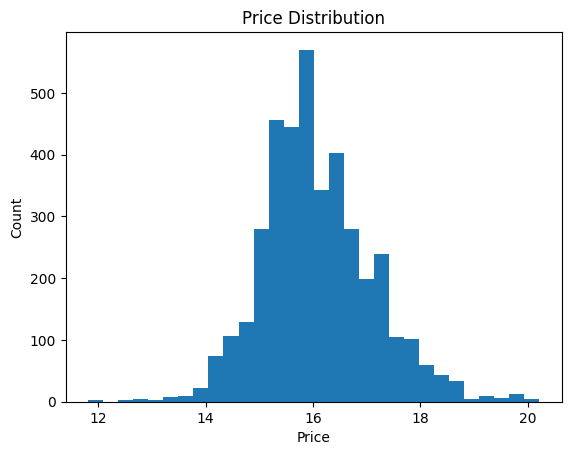

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_clean['log_price'], bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


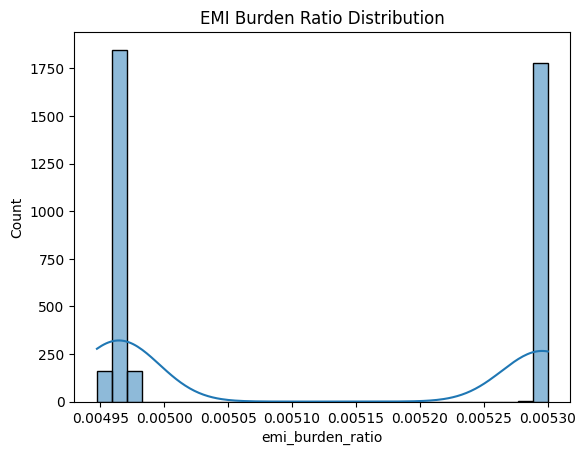

In [ ]:
sns.histplot(df_clean['emi_burden_ratio'], bins=30, kde=True)
plt.title('EMI Burden Ratio Distribution')
plt.show()


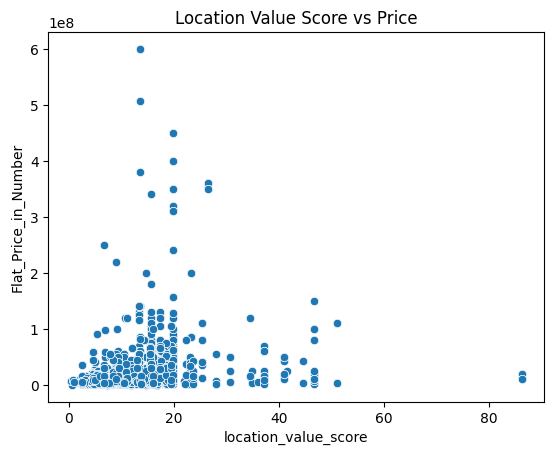

In [ ]:
sns.scatterplot(x='location_value_score', y='Flat_Price_in_Number', data=df_clean)
plt.title('Location Value Score vs Price')
plt.show()


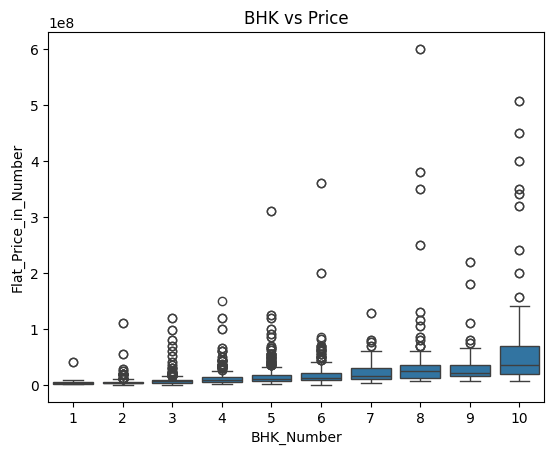

In [ ]:
sns.boxplot(x='BHK_Number', y='Flat_Price_in_Number', data=df_clean)
plt.title('BHK vs Price')
plt.show()


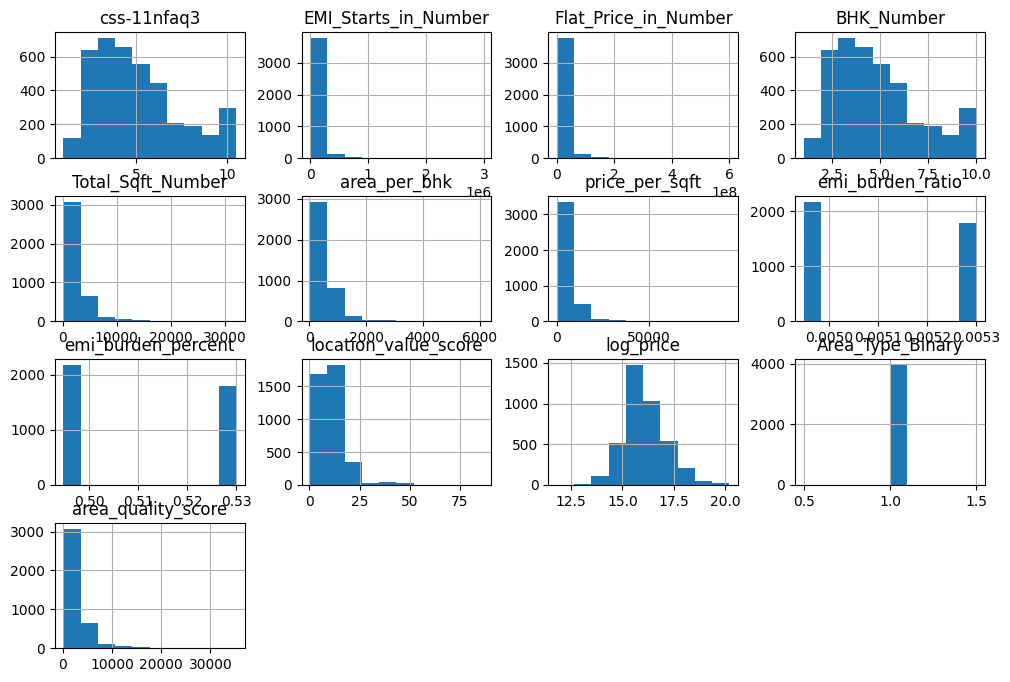

In [ ]:
df_clean.hist(figsize=(12,8))
plt.show()


## Model spliting :

In [ ]:
df_clean.head()

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,House_type,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,...,BHK_Number,Total_Sqft_Number,area_per_bhk,price_per_sqft,emi_burden_ratio,emi_burden_percent,location_value_score,log_price,Area_Type_Binary,area_quality_score
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,...,6,4200.0,700.000000,20238.095238,0.004965,0.496471,19.899420,18.258162,1,4620.0
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,...,3,1400.0,466.666667,3214.285714,0.005296,0.529556,8.431810,15.319588,1,1540.0
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,...,3,2500.0,833.333333,5400.000000,0.004964,0.496444,10.833029,16.418200,1,2750.0
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,...,5,1100.0,220.000000,5454.545455,0.005295,0.529500,12.067590,15.607270,1,1210.0
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,...,4,900.0,225.000000,5777.777778,0.005296,0.529615,5.082570,15.464169,1,990.0


In [ ]:
important_cols = [
    'BHK_Number',
    'Total_Sqft_Number',
    'price_per_sqft',
    'Area_Type_Binary',
    'area_per_bhk',
    'location_value_score',
    'EMI_Starts_in_Number',
    'emi_burden_ratio',
   'area_quality_score',
    'log_price'
]

df_model = df_clean[important_cols]
df_model.head()


,BHK_Number,Total_Sqft_Number,price_per_sqft,Area_Type_Binary,area_per_bhk,location_value_score,EMI_Starts_in_Number,emi_burden_ratio,area_quality_score,log_price
0,6,4200.0,20238.095238,1,700.000000,19.899420,422000.0,0.004965,4620.0,18.258162
1,3,1400.0,3214.285714,1,466.666667,8.431810,23830.0,0.005296,1540.0,15.319588
2,3,2500.0,5400.000000,1,833.333333,10.833029,67020.0,0.004964,2750.0,16.418200
3,5,1100.0,5454.545455,1,220.000000,12.067590,31770.0,0.005295,1210.0,15.607270
4,4,900.0,5777.777778,1,225.000000,5.082570,27540.0,0.005296,990.0,15.464169


In [ ]:
df_model.isnull().sum()
df_model.duplicated().sum()
df_model.dtypes


,0
BHK_Number,int64
Total_Sqft_Number,float64
price_per_sqft,float64
Area_Type_Binary,int64
area_per_bhk,float64
location_value_score,float64
EMI_Starts_in_Number,float64
emi_burden_ratio,float64
area_quality_score,float64
log_price,float64


## model trainig :

In [ ]:
safe_cols = [
    'Total_Sqft_Number',
    'area_quality_score',
    'location_value_score',
    'BHK_Number',
    'area_per_bhk'
]

X = df_clean[safe_cols]
y = df_clean['log_price']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,        # more trees = better stability
    max_depth=18,            # prevent overfitting
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=18, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=4, n_estimators=500, n_jobs=-1,
                      random_state=42)

## model evaluation :

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

preds = rf.predict(X_test)

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


R2: 0.8134874121351291
MAE: 0.28842690790653785
RMSE: 0.42087127634330185


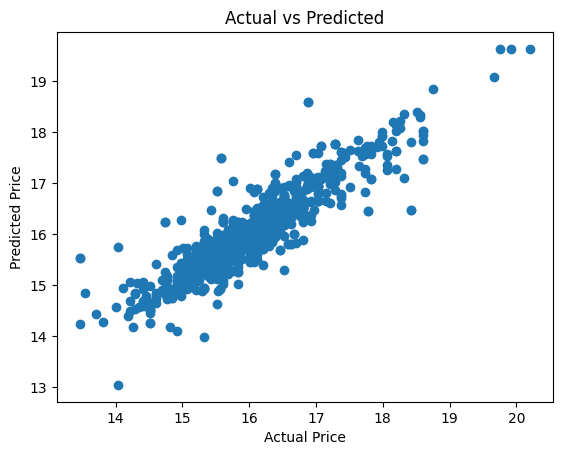

In [ ]:
import matplotlib.pyplot as plt

preds = rf.predict(X_test)

plt.scatter(y_test, preds)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


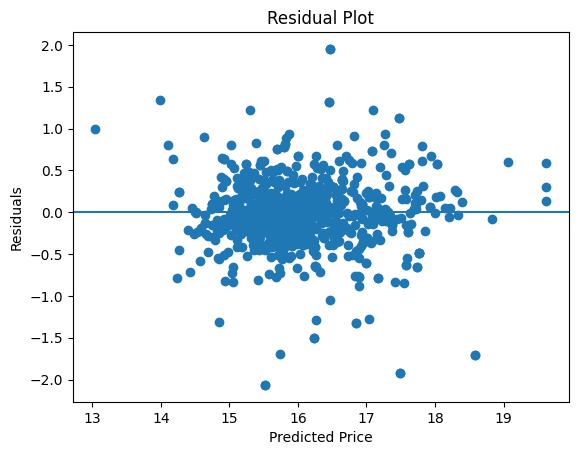

In [ ]:
residuals = y_test - preds

plt.scatter(preds, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


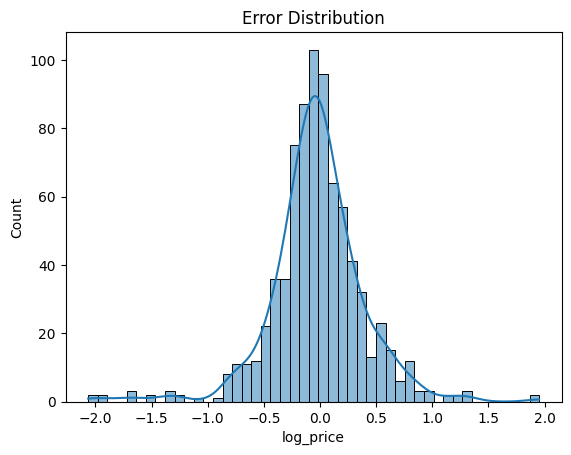

In [ ]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Error Distribution")
plt.show()
